<a href="https://colab.research.google.com/github/lettucebewild/CCMACLRL_COM242ML/blob/main/exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("personality_dataset.csv")

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [2]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


Display the summary of all the features of the dataset using `.info()`

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


Display the total number of samples from each label using `.value_counts()`

In [4]:
df["Personality"].value_counts()

,count
Personality,
Introvert,2502
Extrovert,2498


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

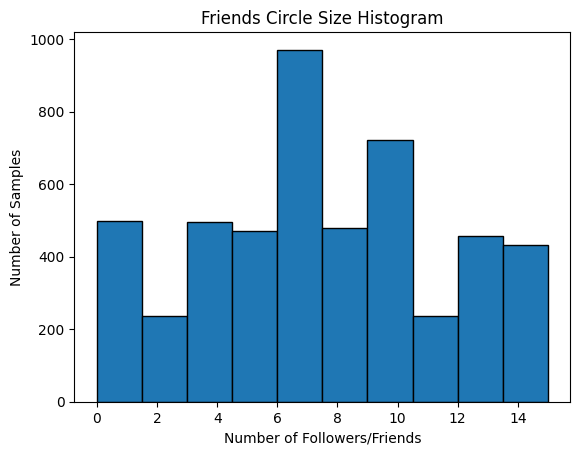

In [5]:
plt.hist(df["Friends_circle_size"], bins=10, edgecolor="black")
plt.xlabel("Number of Followers/Friends")
plt.ylabel("Number of Samples")
plt.title("Friends Circle Size Histogram")
plt.show()

Remove the name column using `drop()` method

In [6]:
# No name column exists in this dataset, so no column is removed
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [7]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le_stage_fear = LabelEncoder()
le_drained = LabelEncoder()
le_y = LabelEncoder()

le_stage_fear.fit(df['Stage_fear'].str.strip().unique())
le_drained.fit(df['Drained_after_socializing'].str.strip().unique())
le_y.fit(df['Personality'].str.strip().unique())

df_processed = df.copy()

df_processed['Stage_fear'] = le_stage_fear.transform(df_processed['Stage_fear'].str.strip())
df_processed['Drained_after_socializing'] = le_drained.transform(df_processed['Drained_after_socializing'].str.strip())
df_processed['Personality'] = le_y.transform(df_processed['Personality'].str.strip())

X = df_processed.drop('Personality', axis=1).values
X = X.astype(float)

y = df_processed['Personality'].values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [8]:
# This cell previously overwrote the preprocessed 'y'. It has been cleared to prevent this issue.
# The 'y' variable is now correctly defined and preprocessed in cell jXLzLDjuVcgI.

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Display the dimensions of each variables using `.shape()`

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 7)
(1000, 7)
(4000,)
(1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [12]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [13]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

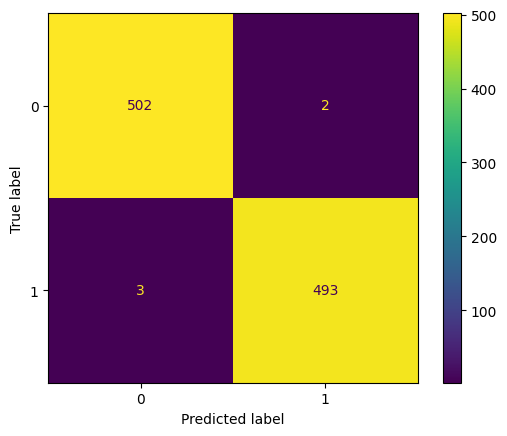

In [14]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(confusion_matrix=cm)

display.plot()
plt.show()

Display the accuracy

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.995


Display the precision

In [16]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.9959595959595959


Display the recall

In [17]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.9939516129032258


Display the f1-score

In [18]:
print("F1-score:", f1_score(y_test, y_pred))

F1-score: 0.9949545913218971


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [19]:
my_features = [[3, 1, 6, 5, 1, 2, 1]]

prediction = knn.predict(my_features)

if prediction[0] == 0:
    print("You are predicted to be Introvert")
else:
    print("You are predicted to be Extrovert")

You are predicted to be Extrovert
